<a href="https://colab.research.google.com/github/frankchieng1982/2048-in-react/blob/master/S64_driving_perception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SLAM

<a href="https://colab.research.google.com/github/gtbook/robotics/blob/master/S64_driving_perception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install -q -U gtbook

In [3]:
%pip install numpy==1.26.4

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt

import plotly.graph_objects as go
try:
    import google.colab
except:
    import plotly.io as pio
    pio.renderers.default = "png"

import gtsam
import gtsam.utils.plot as gtsam_plot

from gtbook.display import show

```{index} perception; SLAM
```

> SLAM is *Simultaneous Localization and Mapping*, a key capability for mobile robots.

<img src="https://github.com/gtbook/robotics/blob/master/Figures6/S64-Autonomous_Vehicle_with_LIDAR_and_cameras-03.jpg?raw=1" alt="Splash image with steampunk autonomous car" width="40%" align=center style="vertical-align:middle;margin:10px 0px">

```{index} pair: SLAM; simultaneous localization and mapping
```

When an autonomous vehicle explores a new environment, it should be able to simultaneously build a map of this environment, and localize itself relative to that map. That capability is known as **Simultaneous Localization and Mapping** or **SLAM**. SLAM is a bit like a chicken and egg problem: if we knew the map, we could use the localization techniques we studied in Section 4.4, e.g., Monte Carlo Localization. Conversely, if we were already localized, it would not be too hard to create a map: if we have a LIDAR sensor, we could simply transform the points from the LIDAR frame into the world frame. But now we have to do *both* at the same time! Is that even possible?

```{index} PoseSLAM, SLAM with landmarks
```
In this section we show that this *is* possible, and we introduce two different SLAM techniques: *PoseSLAM* and *SLAM with landmarks*. In the former we concentrate on estimating the robot's motion from a rich sensor such as LIDAR, and building the map is accomplished as a side effect. In the latter, we truly optimize for both the location of the vehicle and the location of a observed landmarks, which leads to a sparse map of the environment. Before investigating these two SLAM algorithms, we review the math of vehicle poses in 2D, and discuss ICP, a seminal algorithm for aligning two point clouds, and which we use as a building block in PoseSLAM.

## Poses in 2D and 3D

> SE(2) generalizes to SE(3).

In both SLAM variants we need to optimize over the pose of a vehicle.
To keep things simple, we will concentrate on poses in the plane for now.
Recall from Section 6.1 that a 2D pose
$T$ is an element of the Special Euclidean group $SE(2)$,
and can be represented by a $3\times3$ matrix of the form
\begin{equation}
T=\left[\begin{array}{cc|c}
\cos\theta & -\sin\theta & x\\
\sin\theta & \cos\theta & y\\
\hline 0 & 0 & 1
\end{array}\right]=\left[\begin{array}{cc}
R & t\\
0 & 1
\end{array}\right]
\end{equation}
with the $2\times1$ vector $t$
representing the position of the vehicle, and $R$ the $2\times2$
rotation matrix representing the vehicle’s orientation in the plane.

```{index} homogeneous coordinates
```
Below it is important to understand what coordinate frames are involved, and hence we insist on always annotating the transformation matrices with indices indicating the reference frame as superscript and the frame under consideration using subscript.
This convention also provides a reminder of how points in one frame are transformed into the other.
As an example, the following illustrates how points in the frame $b$ are transformed into the reference frame $a$ by referring to the pose $T^a_b$ of frame $b$ in $a$,
\begin{equation}
\tilde P^a = \left[\begin{array}{cc}
R^a_b & t^a_b\\
0 & 1
\end{array}\right] \tilde P^b = T^a_b \tilde P^b
\end{equation}
where as before $\tilde P$ denotes the *homogeneous coordinates* of the point $P$.
A good rule to keep in mind, illustrated above, is that the superscript $b$ of the point $\tilde P^b$ on the right-hand side is "canceled" by the subscript $b$ in the pose $T^a_b$, and so the left-hand side $\tilde P^a$ only retains the superscript $a$, indicating it now lives in the reference frame $a$. This rule is quite useful when implementing these types of transformations in code, as well. Also, keep in mind that we are talking about the *same* point $P$ in both cases: it is simply the *coordinates* that change by expressing them in a different frame.

Note that this representation generalizes easily to three dimensions,
but of course $t^a_b$ will be a three-vector, and $R^a_b$ will be a $3\times3$
rotation matrix representing the 3D orientation of the vehicle. The
latter can be decomposed into roll, pitch, and yaw, if so desired,
but we will not need that until the next chapter.

## The Iterative Closest Points Algorithm

```{index} pair: iterative closest points; ICP
```
> ICP is a seminal method to align two point clouds.

**Iterative closest points** or **ICP** is a method to align two point clouds, e.g., two successive LIDAR scans, and it is a crucial component in the PoseSLAM algorithm we will discuss next. Leaning into the notation re-introduced above, we use superscripts $a$ and $b$ to distinguish the two point clouds, and the points therein. Under the assumption that we have a good initial estimate $\hat{T^a_b}$ for the relative pose $T^a_b$ between the two point clouds, ICP iterates between two steps:

1. Find closest point correspondences between the two clouds.
2. Use these point correspondences to re-estimate the relative pose $\hat{T^a_b}$ between the two point clouds.

These two steps are iterated until convergence, hence the name *iterative* closest points. Below we  explain both steps in more detail.

### Finding Closest Points

The first step is the easiest: for each point $P^a_j$ in the first point cloud, we define $P^b_j$ to be its closest point in the second point cloud. Stated formally, for each point $P^a_j$, we solve the following minimization problem:
\begin{equation}
P^b_j = \arg \min_{P^b_k} \| P^b_k - P^a_j\|^2
\end{equation}
We prefer using indices $j$ for points as we use $i$ for poses below, making it easier to associate notation with geometric concepts. Two things about the above minimization are worth noting:
(a) it can be solved using a linear search over all points $P^b$,
and (b) rather than computing the distance we can save the computation of a square root by minimizing the square, which is just as good as they are monotonically related.

```{index} nearest neighbor, all nearest neighbors, KD-tree, Octree
```
The linear search problem above is known as the **nearest neighbor** problem, and solving this problem for all points is the **all nearest neighbors** problem.
Iterating over all points in the second cloud can be quite slow, and indeed finding all nearest neighbors that way has quadratic complexity. However, very fast *approximate* nearest neighbor algorithms are available. Many of these use specialized data structures, such as *KD-trees* in 2D or Octrees in 3D. While the details are beyond the scope of this book,
intuitively these data structures  recursively divide up the point clouds into sub-clouds, such that sub-clouds unlikely to contain the nearest neighbor can be quickly excluded. We build this data structure once for the second cloud, and then use it for all nearest neighbor searches, leading to complexity which is approximately $O(N \log N$),
for point clouds of size $N$.

### Estimating the Pairwise Transform

```{index} pose alignment
```
The second step is the more interesting one: given a set of closest point pairs $\{(P^a_j, P^b_j)\}$, how can we estimate the relative pose $\widehat{T^a_b}$ between the two point clouds? This is known as the **pose alignment** problem.

```{index} pose alignment
```
Let us first assume that the two point clouds only differ by a rotation $R^a_b$. When this is the case, and assuming we have corresponding points $P^a$ and $P^b$, then each point $P^a$ in the first cloud can be expressed as a function of a point $P^b$ in the second cloud:
\begin{equation}
P^a = R^a_b P^b
\end{equation}
One might be tempted to think that therefore
\begin{equation}
R^a_b = P^a (P^b)^{-1}
\end{equation}
but, of course, since $P^b$ is a vector, it does not have an inverse. So this would not work.
Interestingly, though, if we form the matrix
\begin{equation}
H = \sum_j P^a_j (P^b_j)^T
\end{equation}
by summing over at least 3 point pairs $(P^a_j, P^b_j)$, it turns out that the rotation matrix $\widehat{R^a_b}$ closest to $H$ in the least squares sense *is* the best possible estimate for the unknown rotation $R^a_b$. In addition, using the *singular value decomposition* from linear algebra, it is *very* easy to compute.

```{index} singular value decomposition, orthogonal Procrustes problem
```
The **singular value decomposition** of the matrix $H$ is defined by $H=U\Lambda V^T$, in which $\Lambda$ is a diagonal
matrix of singular values, and both $U$ and $V$ are orthogonal matrices.
The optimal estimate for the rotation matrix is given by
\begin{equation}
\widehat{R^a_b} = U V^T
\end{equation}
Interesting aside: this problem is known as the *orthogonal Procrustes problem* and its solution via SVD has been known since 1966, from a 1966 paper by Peter Schönemann {cite:p}`Schoenemann66_procrustes`. Procrustes was a mythological greek villain who either stretched or cut his victims to size to fit their bed, analogous to how we make the rotation matrix above fit the data.

The above solves the problem when there is only rotation, but we must also consider relative translation between the two point clouds.
Fortunately, it turns out that the best possible translation estimate will always align the *centroids* of the two point clouds. Hence, when there is translation present, we simply compute the matrix $H$ from the *centered* points,
\begin{equation}
H = \sum_j (P^a_j-C^a) (P^b_j-C^b)^T
\end{equation}
where the point cloud centroids $C^a$ and $C^b$ are computed as
\begin{equation}
C^a = \frac{1}{N} \sum_j P^a_j\text{    and    }C^b = \frac{1}{N} \sum_j P^b_j.
\end{equation}
Given the estimated rotation $\widehat{R^a_b}$, the translation estimate $\widehat{t^a_b}$ can then be estimated from
\begin{equation}
C^a = \widehat{R^a_b} C^b + \widehat{t^a_b},
\end{equation}
and the final relative pose estimate is given by $\widehat{T^a_b} =(\widehat{R^a_b}, \widehat{t^a_b})$. By the way, all of the above math is identical for both the 2D and 3D case.

## PoseSLAM

> PoseSLAM is SLAM with pose priors and relative pose constraints only. We can derive those from Iterative Closest Points (ICP).

As we discussed at the beginning of this section, in SLAM the goal is to localize a robot using the information coming
from the robot’s sensors, while simultaneously building the map.
We have already covered the localization problem in chapter 4,
using Markov localization, Monte Carlo localization, and the Kalman filter.
The additional wrinkle in SLAM is that we do
*not* know the map a priori, and hence we have to infer the unknown map
while simultaneously estimating the robot's location with respect to the evolving map.

```{index} PoseSLAM, pose constraints
```
**PoseSLAM** is a variant of SLAM that uses pose constraints (using an algorithm such as ICP) as a
basic building block when optimizing over the unknown vehicle
poses.
In PoseSLAM we do *not* explicitly optimize over a map.
Instead the map is reconstructed after the fact.
This can only work if (a) the sensor is sufficiently rich to make the pose constraints very accurate,
and (b) we can build a sufficiently good map using this sensor data. LIDAR satisfies both of these assumptions,
making LIDAR-based PoseSLAM a very popular technique.

In a nutshell, the PoseSLAM problem can be stated as:

*Given a set of noisy relative measurements or **pose constraints** $\tilde{T}_{ij}$, recover the optimal set of poses $T_{i}^{*}$ that maximizes the posteriori probability, i.e., recover the MAP solution.*

In the case of mapping for autonomous driving, these relative
measurements can be derived by performing ICP between overlapping
LIDAR scans. If available, we can additionally use GPS and/or IMU measurements
to decide which scans overlap, so that we do not have to do this $O(n^{2})$ times.
Depending on the situation, we can optimize for 3D or 2D poses, in the way we will
discus below. Afterwards, we can reconstruct a detailed map by
transforming the local LIDAR scans into the world frame, using the
optimized poses $T_{i}^{*}$.

## The PoseSLAM Factor Graph

> Factor graphs expose the sparse set of constraints tying absolute poses together.

In our factor-graph view of the world, a pose constraint is
represented as a factor. As before, the factor graph represent the
posterior distribution over the unknown pose variables
$\mathcal{T}=\{X_{1}\dots X_{5}\}$ given the known measurements:
\begin{equation}
\phi(\mathcal{T})=\prod_{i}\phi_{i}(\mathcal{T}_{i}),
\end{equation}
where $\mathcal{T}_{i}$ is the set of poses involved with factor $\phi_i$.
In this way, the factor graph encodes which factors are connected to which variables,
exposing the sparsity pattern of the corresponding estimation problem.

<figure id="fig:PoseSLAMFG">
<img src="https://github.com/gtbook/robotics/blob/main/Figures6/PoseSLAM-FG.png?raw=1" style="width:60.0%" /><figcaption>PoseSLAM factor graph example.</figcaption>
</figure>

An example is shown in Figure [1](#fig:PoseSLAMFG). The example represents a vehicle driving around, and taking LIDAR scans
at 5 different world poses, represented by $T_{1}$ to $T_{5}$.
The factors $f_{1}$ to $f_{4}$ are binary factors representing the pose
constraints obtained by matching successive LIDAR scans using ICP.

```{index} loop closure
```
The factor
$f_{5}(T_{5},T_{2})$ is a so-called **loop closure** constraint:
rather than derived from two successive scans, this one is derived from
matching the scan taken at $T_{5}$ with the one at $T_{2}$.
Detecting such loops can be done through a variety of means. The final,
unary factor $f_{0}(T_{1})$ is there to “anchor” the solution to the
origin: if it is not there, the solution will be undetermined. Another
way to anchor the solution is to add unary factors at every time-step,
derived from GPS.

## MAP Inference via Least Squares

> Linear problems with zero-mean Gaussian noise lead to least-squares problems.

When measurements are linear functions of continuous variables,
finding the maximum a posteriori (MAP) solution can be done via
least-squares optimization.
Earlier in this book we have discussed MAP inference for discrete
variables, and we have discussed probability distributions for
continuous variables, but we have never put the two together.

```{index} mean, variance
```
In the case of linear measurements corrupted by zero-mean Gaussian noise, we can
recover the MAP solution by minimizing a sum of squared differences.
Recall that a univariate Gaussian density with **mean** $\mu$ and **variance** $\sigma^{2}$ is
given by
\begin{equation}
\mathcal{N} (x; \mu, \sigma^2) =\frac{1}{\sqrt{2\pi\sigma^{2}}}\exp\left\{ -\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^{2}\right\} .
\end{equation}

An example can help explain this more clearly.
In particular, if we focus our attention in PoseSLAM on *just the x coordinates*.
Let us denote the *relative measurements* $\tilde{x}_{ij}$, predicted by
\begin{equation}
\tilde{x}_{ij}\approx h(x_{i,}x_{j})=x_{j}-x_{i}
\end{equation}
and, taking $\sigma=1$ for now, each factor in Figure [1](#fig:PoseSLAMFG) could be written as
\begin{equation}
\phi(x_{i},x_{j})=\frac{1}{\sqrt{2\pi}}\exp\left\{ -\frac{1}{2}\left(x_{j}-x_{i}-\tilde{x}_{ij}\right)^{2}\right\} ,
\end{equation}
By taking the negative log,
maximizing the posterior corresponds to minimizing the following sum of
squares, where the sum ranges over all $(i,j)$ pairs for which we have a
pairwise measurement:
\begin{equation}
\mathcal{X}^{*}=\arg\min_{\mathcal{X}}\sum_{k}\frac{1}{2}\left(h(x_{i},x_{j})-\tilde{x}_{ij}\right)^{2}=\arg\min_{\mathcal{X}}\sum_{k}\frac{1}{2}\left(x_{j}-x_{i}-\tilde{x}_{ij}\right)^{2}.
\end{equation}
The minimization is over the set of all unknown poses $\mathcal{X}\doteq\{x_i\}$ and yields the MAP estimate $\mathcal{X}^{*}$ for the poses.
Linear least-squares problems like these are easily solved by numerical
computing packages like MATLAB or `numpy`.

## PoseSLAM is Nonlinear !

> Nonlinear problems need nonlinear solutions.

Unfortunately, in the PoseSLAM case we cannot use linear least squares,
because poses are not simply vectors, and the measurements are not
simply linear functions of the poses. Indeed, in PoseSLAM both the
prediction $h(T_{i},T_{j})$ and the measurement $\tilde{T}_{ij}$
are relative poses. The measurement prediction function $h(\cdot)$ is given
by the *relative transformation* $T_ij \doteq T_{i}^{-1}T_{j}$:
\begin{equation}
h(T_{i},T_{j})=T_{i}^{-1}T_{j}.
\end{equation}
Hence, the measurement error to be minimized is
\begin{equation}
\frac{1}{2}\left\Vert \log\left(\tilde{T}_{ij}^{-1}T_{i}^{-1}T_{j}\right)\right\Vert ^{2}
\end{equation}
where $\log:SE(2)\rightarrow\mathbb{R}^3$ is a variation of the logarithm function
that maps a pose in $SE(2)$ to a
three-dimensional local coordinate vector $\xi$.
We will describe this in more detail below.

```{index} nonlinear optimization, rotation averaging
```
There are two ways to deal with this nonlinear problem. The first is to
realize that the only nonlinearities stem from the $\sin$ and $\cos$
that are associated with the unknown orientations
$\theta_{i}$.
Recognizing this, we could try to solve for the
orientations first, and then solve for the translations using linear
least squares, exactly as above. This approach is known as **rotation
averaging** followed by linear translation recovery. Unfortunately this approach is
suboptimal, as it does not consider the orientation and translation
simultaneously. However, it can serve to provide a (very) good initial
estimate for nonlinear optimization, discussed below.

Indeed, we will prefer to take a second route, which is to use
**nonlinear optimization**, which we discuss below.

## Nonlinear Optimization for PoseSLAM

> Linearize, solve, repeat...

At first glance, minimizing the measurement error might seem to be a straightforward
nonlinear optimization problem: simply use your favorite nonlinear optimizer, e.g., with
an initial estimate provided using the method in the previous section.
This approach might well succeed in finding matrices $T_i$ that minimize the error,
but, unfortunately, there is no guarantee that $T_i \in SE(2)$, since
this approach does not ensure that the upper left submatrix is a valid rotation matrix.

Instead, we will locally linearize the problem and solve
the corresponding linear problem using least squares, and iterate this
until convergence. We do this by, at each iteration, parameterizing a
pose $T$ by
\begin{equation}
T\approx\bar{T}\Delta(\xi)
\end{equation}
where $\xi \doteq (\delta x,\delta y,\delta\theta)$ is a 3-vector of local coordinates,
and the incremental pose $\Delta(\xi)\in SE(2)$ is defined as
\begin{equation}
\Delta(\xi)=\left[\begin{array}{cc|c}
1 & -\delta\theta & \delta x\\
\delta\theta & 1 & \delta y\\
\hline 0 & 0 & 1
\end{array}\right]
\end{equation}
which you can recognize as a small angle
approximation of the $SE(2)$ matrix, since $\cos \theta \approx 1$ and $\sin \theta \approx \theta$ for small $\theta$.

```{index} Jacobian matrix
```
In 3D the local coordinate vector $\xi$ is *6-dimensional*, and the small angle
approximation is defined as
```{math}
:label: eq:delta3d
\begin{equation}
\Delta(\xi)=\left[\begin{array}{ccc|c}
1 & -\delta\theta_{z} & \delta\theta_{y} & \delta x\\
\delta\theta_{z} & 1 & -\delta\theta_{x} & \delta y\\
-\delta\theta_{y} & \delta\theta_{x} & 1 & \delta z\\
\hline 0 & 0 & 0 & 1
\end{array}\right]
\end{equation}
```
with $\xi \doteq (\theta_{x},\theta_{y},\theta_{z},\delta x,\delta y,\delta z)$.
It is well known that in this case we can also approximate the
nonlinear error by the following linear approximation:
\begin{equation}
\frac{1}{2}\left\Vert \log\left(\tilde{T}_{ij}^{-1}T_{i}^{-1}T_{j}\right)\right\Vert ^{2}\approx\frac{1}{2}\left\Vert A_{i}\xi_{i}+A_{j}\xi_{j}-b\right\Vert ^{2}.
\end{equation}
For $SE(2)$ the matrices $A_{i}$ and $A_{j}$ are the $3\times3$
**Jacobian matrices** and $b$ is a $3\times1$ bias term. The above
provides a linear approximation of the term within the norm as a
function of the incremental local coordinates $\xi_{i}$ and $\xi_{j}$.
Deriving the detailed expressions for these Jacobians is beyond the
scope of this book, but suffice to say that they exist and are not too
expensive to compute. In three dimensions, the Jacobian matrices are
$6\times6$ and $16\times6$, respectively.

The final optimization will—in each iteration—minimize over the local
coordinates of all poses by summing over all pose constraints.
If we index those constraints by $k$, we have the following least-squares
problem:
\begin{equation}
\Xi^{*}=\arg\min_{\Xi}\sum_{k}\frac{1}{2}\Vert A_{ki}\xi_{i}+A_{kj}\xi_{j}-b_{k}\Vert ^{2}
\end{equation}
where $\Xi\doteq \{  \xi_{i}\}$, the set
of all incremental pose coordinates.
After solving for the incremental updates $\Xi$, we update all poses
using
\begin{equation}
T_i\approx\bar{T}_i\Delta(\xi_i),
\end{equation}
with $\Delta(\xi_i)$ defined as in {eq}`eq:delta3d`.

We then check for convergence: if the error does not decrease significantly
we terminate, otherwise we linearize and solve again, until the error
converges. While this is not guaranteed to converge to a global minimum,
in practice it does so if there are enough relative measurements and a
good initial estimate is available. For example, GPS can provide us with
a good initial estimate. However, especially in urban environments GPS
can be quite noisy, and it could happen that the map quality suffers by
converging to a bad local minimum. Hence, a good quality control process
is absolutely necessary in production environments.

In summary, the algorithm for nonlinear optimization is

-   Start with an initial estimate $\mathcal{T}^{0}$

-   Iterate:

    1.  Linearize the factors
$\frac{1}{2}\Vert \log(\tilde{T}_{ij}^{-1}T_{i}^{-1}T_{j})\Vert ^{2}\approx\frac{1}{2}\Vert A_{i}\xi_{i}+A_{j}\xi_{j}-b\Vert ^{2}$

    2.  Solve the least-squares problem
        $\Xi^{*}=\arg\min_{\Xi}\sum_{k}\frac{1}{2}\Vert A_{ki}\xi_{i}+A_{kj}\xi_{j}-b_{k}\Vert ^{2}$

    3.  Update $X_{i}^{t+1}\leftarrow X_{j}^{t}\Delta(\xi_{i})$

-   Until the nonlinear error $\sum_{k}\frac{1}{2}\Vert \log(\tilde{T}_{ij}^{-1}T_{i}^{-1}T_{j})\Vert ^{2}$ converges.

## Optimization with GTSAM

> GTSAM rocks PoseSLAM.

For SLAM we typically use specialized packages such as GTSAM that
exploit the sparsity of the factor graphs to dramatically
speed up computation.
Typically
measurements only provide information on the relationship between a
handful of variables, and hence the resulting factor graph will be
sparsely connected. This is exploited by the algorithms implemented in
GTSAM to reduce computational complexity. Even when graphs are too dense
to be handled efficiently by direct methods, GTSAM provides iterative
methods that are quite efficient.

```{index} loop closure
```
The code in Figure [2](#fig:createPoseSLAMFG), included in GTSAM as an example, creates the factor graph from Figure [1](#fig:PoseSLAMFG).
The first block of code creates a nonlinear factor graph and adds the unary factor
$f_{0}(T_{1})$.
As the vehicle travels through the world, it adds
binary factors $f_{t}(T_{t},T_{t+1})$ corresponding to odometry measurements.
Note that the final line of code models a different event: a **loop closure**.
For example,
the vehicle might recognize the same location using vision or a laser
range finder, and calculate the geometric pose constraint to when it
first visited this location. This is illustrated for poses $T_{5}$
and $T_{2}$, and generates the (red) loop closing factor
$f_{5}(T_{5},T_{2})$.

In [5]:
#| caption: Code to re-create the factor graph from Figure [1](#fig:PoseSLAMFG).
#| label: fig:createPoseSLAMFG
graph = gtsam.NonlinearFactorGraph()
prior_model = gtsam.noiseModel.Diagonal.Sigmas((0.3, 0.3, 0.1))
graph.add(gtsam.PriorFactorPose2(1, gtsam.Pose2(0, 0, 0), prior_model))

# Create odometry (Between) factors between consecutive poses
odometry_model = gtsam.noiseModel.Diagonal.Sigmas((0.2, 0.2, 0.1))
Between = gtsam.BetweenFactorPose2
graph.add(Between(1, 2, gtsam.Pose2(2, 0, 0), odometry_model))
graph.add(Between(2, 3, gtsam.Pose2(2, 0, np.pi/2), odometry_model))
graph.add(Between(3, 4, gtsam.Pose2(2, 0, np.pi/2), odometry_model))
graph.add(Between(4, 5, gtsam.Pose2(2, 0, np.pi/2), odometry_model))

# Add the loop closure constraint
graph.add(Between(5, 2, gtsam.Pose2(2, 0, np.pi/2), odometry_model))

Before we can optimize, we need to create an initial estimate. In GTSAM, this is done via the `Values` type, as shown in Figure [3](#fig:create-initial-estimate). We can use this initial estimate to `show` the factor graph in Figure [4](#fig:factor_graph_with_loop_closure). It does not look as pretty as the hand-crafted figure, but it has the advantage that it can be programmatically generated.

In [6]:
#| caption: Create the initial estimate.
#| label: fig:create-initial-estimate
initial_estimate = gtsam.Values()
initial_estimate.insert(1, gtsam.Pose2(0.5, 0.0, 0.2))
initial_estimate.insert(2, gtsam.Pose2(2.3, 0.1, -0.2))
initial_estimate.insert(3, gtsam.Pose2(4.1, 0.1, np.pi/2))
initial_estimate.insert(4, gtsam.Pose2(4.0, 2.0, np.pi))
initial_estimate.insert(5, gtsam.Pose2(2.1, 2.1, -np.pi/2))
print(initial_estimate)

Values with 5 values:
Value 1: (gtsam::Pose2)
(0.5, 0, 0.2)

Value 2: (gtsam::Pose2)
(2.3, 0.1, -0.2)

Value 3: (gtsam::Pose2)
(4.1, 0.1, 1.5708)

Value 4: (gtsam::Pose2)
(4, 2, 3.14159)

Value 5: (gtsam::Pose2)
(2.1, 2.1, -1.5708)




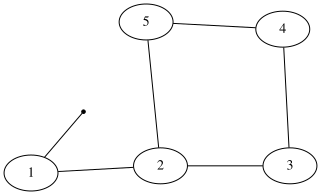

In [7]:
#| caption: Factor graph with odometry and loop closure constraints.
#| label: fig:factor_graph_with_loop_closure
show(graph, initial_estimate, binary_edges=True)

Optimization is done using nonlinear minimization, as explained above. In GTSAM, this is done via a `NonlinearOptimizer` class. The specific optimizer we use below is `GaussNewtonOptimizer`, which exactly implements the pseudocode given above, but exploiting sparsity in the factor graph to do this very efficiently. The optimizer only needs a graph and an initial estimate, both of which we already created. Hence the code, shown in Figure [5](#fig:optimize-graph) is quite simple; the final optimized result is shown there as well, albeit as plain text.

In [8]:
#| caption: Optimize the initial values using a Gauss-Newton nonlinear optimizer.
#| label: fig:optimize-graph
optimizer = gtsam.GaussNewtonOptimizer(graph, initial_estimate)
result = optimizer.optimize()
print("Final Result:\n{}".format(result))

Final Result:
Values with 5 values:
Value 1: (gtsam::Pose2)
(-2.76843e-20, -8.152e-20, -3.57721e-20)

Value 2: (gtsam::Pose2)
(2, -1.89295e-19, -5.34287e-20)

Value 3: (gtsam::Pose2)
(4, -3.42174e-11, 1.5708)

Value 4: (gtsam::Pose2)
(4, 2, 3.14159)

Value 5: (gtsam::Pose2)
(2, 2, -1.5708)




```{index} posterior marginals
```
We can also inspect the result graphically. Looking at the result as printed above only gets us so far, and more importantly, it only shows us the maximum a posteriori (MAP) solution, but not the uncertainty around it. Luckily, GTSAM can also compute the **posterior marginals**, which show the uncertainty on each recovered pose as a conditional Gaussian density $P(T_i|Z)$, taking into account all the measurements $Z$.

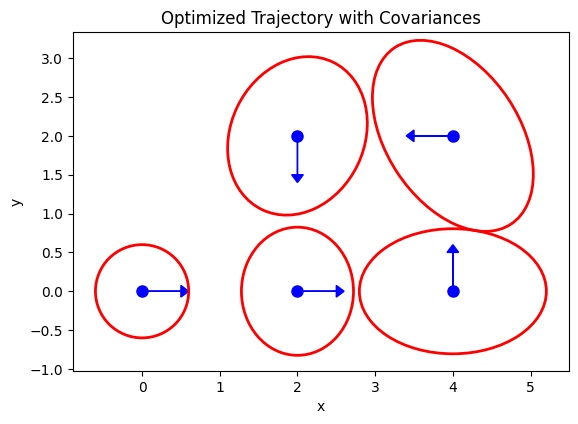

In [9]:
#| caption: The optimized trajectory with the estimated covariances.
#| label: fig:optimized_trajectory_with_covariances
# marginals = gtsam.Marginals(graph, result)
# for i in range(1, 6):
#     gtsam_plot.plot_pose2(0, result.atPose2(i), 0.5,
#                           marginals.marginalCovariance(i))
# plt.axis('equal'); plt.show()
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import gtsam

marginals = gtsam.Marginals(graph, result)
fig, ax = plt.subplots()

for i in range(1, 6):
    pose = result.atPose2(i)
    x, y, theta = pose.x(), pose.y(), pose.theta()

    # Plot pose position
    ax.plot(x, y, 'bo', markersize=8)

    # Draw heading arrow
    ax.arrow(x, y, 0.5 * np.cos(theta), 0.5 * np.sin(theta),
             head_width=0.15, head_length=0.1, fc='blue', ec='blue')

    # Get and convert covariance to native numpy float64
    cov = np.asarray(marginals.marginalCovariance(i), dtype=np.float64)

    # Extract x-y covariance (top-left 2×2 block)
    cov_xy = cov[:2, :2]

    # Compute 2-sigma ellipse parameters
    eigenvalues, eigenvectors = np.linalg.eigh(cov_xy)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * np.sqrt(eigenvalues) * 2  # 2-sigma

    ellipse = Ellipse(xy=(x, y), width=width, height=height,
                      angle=angle, edgecolor='red', facecolor='none', linewidth=2)
    ax.add_patch(ellipse)

ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Optimized Trajectory with Covariances')
plt.show()

In code, we do this via the `Marginals` object, and we can plot marginals with a special function `plot_pose2`, as shown in Figure [6](#fig:optimized_trajectory_with_covariances), which also shows the result graphically along with covariance ellipses. These covariance ellipses
in 2D indicate the marginal over position, *over all possible
orientations*, and show the area that contains 99% of the probability
mass (in 1D this would correspond to three standard deviations). The graph
shows in a clear manner that the uncertainty on pose $T_{5}$ is now
much less than if there would be only odometry measurements. The pose
with the highest uncertainty, $T_{4}$, is the one furthest away from
the unary constraint $f_{0}(T_{1})$, which is the only factor tying
the graph to a global coordinate frame.

## SLAM with Landmarks

> Take PoseSLAM, add landmarks.

So far we optimized over one type of variable, but often we build a landmark map *simultaneously* with the trajectory, i.e., this is *true* SLAM. In the next chapter, we will more thoroughly examine the full 3D case, whereas here we will model landmarks with 2D points in the plane. That does not mean that they cannot represent real 3D entities in the environment: they can be the location of trees, poles, building corners, the sides of windows, the location of a stop sign in traffic, even moving pedestrians in more advanced applications.

```{index} range measurement, bearing measurement, bearing-range measurement
```
How do we measure such landmarks? The most typical *type* of measurements are either **range** measurements, **bearing** measurements, or **bearing-range** measurements. The details on how to obtain them are typically application-dependent, and below we will abstract away the sensor preprocessing details. For example, in the case of a LIDAR sensor,
bearing-range measurements can be obtained by preprocessing every LIDAR scan, detecting prominent vertical structures for example. A real-life example that we will discuss below involves detecting and measuring the bearing-range to trees.
Radar is another often-used sensor for autonomous driving, and it can often be modeled or idealized to give
bearing-range measurements as well.

To illustrate SLAM with landmarks, we build a small toy example with 3 bearing-range measurements to two different landmarks:

In [10]:
slam_graph = gtsam.NonlinearFactorGraph()
slam_graph.add( gtsam.PriorFactorPose2(1, gtsam.Pose2(0.0, 0.0, 0.0), prior_model))
slam_graph.add(Between(1, 2, gtsam.Pose2(2.0, 0.0, 0.0), odometry_model))
slam_graph.add(Between(2, 3, gtsam.Pose2(2.0, 0.0, 0.0), odometry_model))

In [11]:
# Add Range-Bearing measurements to two different landmarks L1 and L2
measurement_model = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.1, 0.2]))
BR = gtsam.BearingRangeFactor2D
l = {k:gtsam.symbol('l',k) for k in [1,2]} # name landmark variables
slam_graph.add(BR(1, l[1], gtsam.Rot2.fromDegrees(45),np.sqrt(4.0 + 4.0), measurement_model)) # pose 1 -*- landmark 1
slam_graph.add(BR(2, l[1], gtsam.Rot2.fromDegrees(90), 2.0,measurement_model)) # pose 2 -*- landmark 1
slam_graph.add(BR(3, l[2], gtsam.Rot2.fromDegrees(90), 2.0,measurement_model)) # pose 3 -*- landmark 2

When we have an initial estimate, we can look at the structure of this factor graph. We create the initial estimate and show the resulting factor graph in Figure [7](#fig:factor_graph_with_range_bearing).

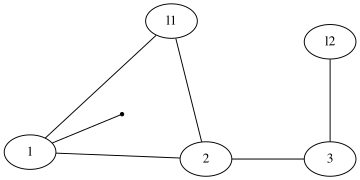

In [12]:
#| caption: Factor graph with odometry and range-bearing constraints.
#| label: fig:factor_graph_with_range_bearing
slam_initial = gtsam.Values()
slam_initial.insert(1, gtsam.Pose2(-0.25, 0.20, 0.15))
slam_initial.insert(2, gtsam.Pose2(2.30, 0.10, -0.20))
slam_initial.insert(3, gtsam.Pose2(4.10, 0.10, 0.10))
slam_initial.insert(l[1], gtsam.Point2(1.80, 2.10))
slam_initial.insert(l[2], gtsam.Point2(4.10, 1.80))
show(slam_graph, slam_initial, binary_edges=True)

We optimize again using Levenberg Marquardt, and show the marginals on both robot position and landmarks, as before, in Figure [8](#fig:fig:optimized_trajectory_with_covariances_and_landmarks_br).

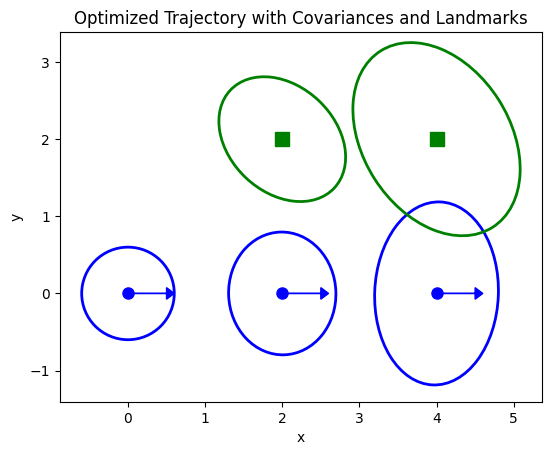

In [13]:
#| caption: The optimized trajectory with the estimated covariances, with bearing-range measurements to landmarks.
#| label: fig:optimized_trajectory_with_covariances_and_landmarks_br
# optimizer = gtsam.LevenbergMarquardtOptimizer(slam_graph, slam_initial)
# slam_result = optimizer.optimize()
# marginals = gtsam.Marginals(slam_graph, slam_result)
# for k in [1,2,3]:
#     gtsam_plot.plot_pose2(0, slam_result.atPose2(k), 0.5, marginals.marginalCovariance(k))
# for j in [1,2]:
#     gtsam_plot.plot_point2(0, slam_result.atPoint2(l[j]), 'g', P=marginals.marginalCovariance(l[j]))
# plt.axis('equal'); plt.show()
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import gtsam

# Optimize and compute marginals
optimizer = gtsam.LevenbergMarquardtOptimizer(slam_graph, slam_initial)
slam_result = optimizer.optimize()
marginals = gtsam.Marginals(slam_graph, slam_result)

fig, ax = plt.subplots()

def plot_covariance_ellipse(ax, center, cov, n_std=2.0, **kwargs):
    """Plot a covariance ellipse at center from 2x2 covariance matrix."""
    cov = np.asarray(cov, dtype=np.float64)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)

    ellipse = Ellipse(xy=center, width=width, height=height,
                      angle=angle, **kwargs)
    ax.add_patch(ellipse)

# Plot poses (keys 1, 2, 3)
for k in [1, 2, 3]:
    pose = slam_result.atPose2(k)
    x, y, theta = pose.x(), pose.y(), pose.theta()

    # Pose marker and heading arrow
    ax.plot(x, y, 'bo', markersize=8)
    ax.arrow(x, y, 0.5 * np.cos(theta), 0.5 * np.sin(theta),
             head_width=0.15, head_length=0.1, fc='blue', ec='blue')

    # Pose x-y covariance (top-left 2x2 of 3x3 marginal)
    cov = np.asarray(marginals.marginalCovariance(k), dtype=np.float64)
    plot_covariance_ellipse(ax, (x, y), cov[:2, :2],
                            n_std=2.0, edgecolor='blue', facecolor='none', linewidth=2)

# Plot landmarks (keys l[1], l[2])
for j in [1, 2]:
    key = l[j]
    point = slam_result.atPoint2(key)

    # atPoint2 may return ndarray — index it directly
    px, py = float(point[0]), float(point[1])

    # Landmark marker
    ax.plot(px, py, 'gs', markersize=10)

    # Landmark covariance
    cov = np.asarray(marginals.marginalCovariance(key), dtype=np.float64)
    plot_covariance_ellipse(ax, (px, py), cov,
                            n_std=2.0, edgecolor='green', facecolor='none', linewidth=2)

ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Optimized Trajectory with Covariances and Landmarks')
plt.show()

## A Larger SLAM Example

Below we optimize a piece of the (old) [Victoria park dataset](http://www-personal.acfr.usyd.edu.au/nebot/victoria_park.htm), which involves a truck driving through a park in Sydney, extracting the position of trees in the park from LIDAR scans, just as we discussed above. The factor graph for this example is created from a file and shown in Figure [9](#fig:factor_graph_real_world).

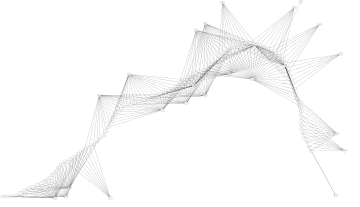

In [14]:
#| caption: Factor graph for a more realistic example, derived from a real-world dataset.
#| label: fig:factor_graph_real_world
datafile = gtsam.findExampleDataFile('example.graph')
model = gtsam.noiseModel.Diagonal.Sigmas([0.05,0.05,2*math.pi/180])
[graph,initial] = gtsam.load2D(datafile, model)
show(graph,initial, binary_edges=True)

This is a much larger factor graph than any we have encountered before, and we can distinguish several features:

- There is a prominent backbone of truck poses, connected via odometry measurements.
- There are about 20 landmarks, some of which are seen briefly, while others are seen for longer periods of time.
- The graph is very sparsely connected, and hence optimization will still be quite fast.

{raw:tex}`noindent`
Optimizing with `LevenbergMarquardtOptimizer`, again:

In [15]:
initial_poses = gtsam.utilities.extractPose2(initial)
for i in range(initial_poses.shape[0]):
    initial.update(i, initial.atPose2(i).retract(np.random.normal(scale=0.5,size=(3,))))
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial)
result = optimizer.optimize()

In Figure [10](#fig:initial_and_optimized_trajectories) we plot both the initial estimate, which was created by adding random noise on top of the ground truth, and the optimized trajectory.

In [16]:
#| caption: Initial and optimized trajectories for a more realistic example.
#| label: fig:initial_and_optimized_trajectories
initial_poses = gtsam.utilities.extractPose2(initial)
fig = go.Figure()
fig.add_scatter(x=initial_poses[:,0], y=initial_poses[:,1], name="initial", marker=dict(color='orange'))
final_poses = gtsam.utilities.extractPose2(result)
fig.add_scatter(x=final_poses[:,0], y=final_poses[:,1], name="optimized", marker=dict(color='green'))
fig.update_yaxes(scaleanchor = "x",scaleratio = 1);
fig.show()

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.


